<a href="https://colab.research.google.com/github/Mahimajha07/EUTO-SAT---land-cover-classification-/blob/main/sentinel2_change_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import kagglehub
path = kagglehub.dataset_download("soumikrakshit/onera-satellite-change-detection-dataset")

Using Colab cache for faster access to the 'onera-satellite-change-detection-dataset' dataset.


In [16]:
!pip install -q kagglehub rasterio scikit-image #1

In [17]:
import kagglehub #2
path = kagglehub.dataset_download("soumikrakshit/onera-satellite-change-detection-dataset")
print(path)

Using Colab cache for faster access to the 'onera-satellite-change-detection-dataset' dataset.
/kaggle/input/onera-satellite-change-detection-dataset


In [18]:
import os #3
for dirpath, dirnames, filenames in os.walk(path):
    depth = dirpath.replace(path, "").count(os.sep)
    if depth <= 2:
        print("  "*depth + os.path.basename(dirpath) + "/")

onera-satellite-change-detection-dataset/
  images/
    Onera Satellite Change Detection dataset - Images/
  train_labels/
    Onera Satellite Change Detection dataset - Train Labels/


In [19]:
import os
import glob
import numpy as np
import rasterio
from PIL import Image
import torch
from torch.utils.data import Dataset

BANDS = ["B01","B02","B03","B04","B05","B06","B07","B08","B8A","B09","B10","B11","B12"]
RED_IDX = BANDS.index("B04")
NIR_IDX = BANDS.index("B08")

def _find_dir(root, *keywords):
    for dirpath, dirnames, _ in os.walk(root):
        name = os.path.basename(dirpath).lower()
        if all(k in name for k in keywords):
            return dirpath
    return None

def _find_all_dirs(root, *keywords):
    found = []
    for dirpath, dirnames, _ in os.walk(root):
        name = os.path.basename(dirpath).lower()
        if all(k in name for k in keywords):
            found.append(dirpath)
    return found

def _find_city_dirs(images_root):
    cities = {}
    for dirpath, dirnames, filenames in os.walk(images_root):
        if "imgs_1" in [d.lower() for d in dirnames] or "imgs_1_rect" in [d.lower() for d in dirnames]:
            cities[os.path.basename(dirpath)] = dirpath
    return cities

def _load_bands(city_dir, sub_candidates):
    for sub in sub_candidates:
        band_dir = os.path.join(city_dir, sub)
        if os.path.isdir(band_dir):
            raw_arrs = []
            for b in BANDS:
                matches = glob.glob(os.path.join(band_dir, f"*{b}*.tif")) + \
                          glob.glob(os.path.join(band_dir, f"*{b}*.tiff"))
                if not matches:
                    raise FileNotFoundError(f"band {b} not found in {band_dir}")
                with rasterio.open(matches[0]) as src:
                    raw_arrs.append(src.read(1).astype(np.float32))
            # Sentinel-2 bands are natively 10m/20m/60m, so raw tifs differ in
            # pixel dimensions. Resample every band up to the highest-resolution
            # band's grid (bilinear) so all 13 bands stack into one array.
            target_h = max(a.shape[0] for a in raw_arrs)
            target_w = max(a.shape[1] for a in raw_arrs)
            arrs = []
            for a in raw_arrs:
                if a.shape != (target_h, target_w):
                    a = np.array(
                        Image.fromarray(a).resize((target_w, target_h), Image.BILINEAR),
                        dtype=np.float32,
                    )
                arrs.append(a)
            return np.stack(arrs, axis=0)
    raise FileNotFoundError(f"no imgs dir found under {city_dir}")

def _find_label(labels_roots, city):
    for labels_root in labels_roots:
        patterns = [
            os.path.join(labels_root, city, "cm", "*.png"),
            os.path.join(labels_root, city, "cm", "*.tif"),
            os.path.join(labels_root, city, "*.png"),
            os.path.join(labels_root, city, "*.tif"),
        ]
        for p in patterns:
            matches = glob.glob(p)
            if matches:
                return matches[0]
    return None

def _binarize_label(raw):
    """OSCD change masks use inconsistent encodings across mirrors: some use
    0/255, others use 1 (no-change)/2 (change). In every known convention the
    'change' class is the higher pixel value, so thresholding at the midpoint
    between min and max is encoding-agnostic."""
    raw = raw.astype(np.float32)
    lo, hi = raw.min(), raw.max()
    if hi <= lo:
        return np.zeros(raw.shape, dtype=np.uint8)
    mid = (lo + hi) / 2.0
    return (raw > mid).astype(np.uint8)

class OSCDDataset(Dataset):
    def __init__(self, root, cities=None, patch_size=96, stride=None, normalize=True, require_labels=True):
        self.root = root
        images_root = _find_dir(root, "image") or root
        labels_roots = _find_all_dirs(root, "label") or [root]
        self.city_dirs = _find_city_dirs(images_root)
        if cities is not None:
            self.city_dirs = {c: d for c, d in self.city_dirs.items() if c in cities}
        if not self.city_dirs:
            raise RuntimeError(f"no cities found under {images_root}")

        self.patch_size = patch_size
        self.stride = stride or patch_size
        self.normalize = normalize
        self.samples = []

        for city, city_dir in self.city_dirs.items():
            img1 = _load_bands(city_dir, ["imgs_1", "imgs_1_rect"])
            img2 = _load_bands(city_dir, ["imgs_2", "imgs_2_rect"])
            label_path = _find_label(labels_roots, city)
            if label_path is None:
                if require_labels:
                    continue
                label = np.zeros(img1.shape[1:], dtype=np.uint8)
            else:
                label = _binarize_label(np.array(Image.open(label_path).convert("L")))

            h = min(img1.shape[1], img2.shape[1], label.shape[0])
            w = min(img1.shape[2], img2.shape[2], label.shape[1])
            if h < self.patch_size or w < self.patch_size:
                continue  # city smaller than patch size; skip rather than emit a truncated patch
            img1, img2, label = img1[:, :h, :w], img2[:, :h, :w], label[:h, :w]

            for y in range(0, max(h - self.patch_size, 0) + 1, self.stride):
                for x in range(0, max(w - self.patch_size, 0) + 1, self.stride):
                    self.samples.append((city, img1, img2, label, y, x))

    def __len__(self):
        return len(self.samples)

    def _norm(self, patch):
        p = patch.copy()
        for c in range(p.shape[0]):
            band = p[c]
            lo, hi = np.percentile(band, 2), np.percentile(band, 98)
            if hi > lo:
                band = np.clip((band - lo) / (hi - lo), 0, 1)
            else:
                band = np.zeros_like(band)
            p[c] = band
        return p

    def __getitem__(self, idx):
        city, img1, img2, label, y, x = self.samples[idx]
        ps = self.patch_size
        p1 = img1[:, y:y+ps, x:x+ps]
        p2 = img2[:, y:y+ps, x:x+ps]
        lbl = label[y:y+ps, x:x+ps]
        if self.normalize:
            p1 = self._norm(p1)
            p2 = self._norm(p2)
        return (
            torch.from_numpy(p1).float(),
            torch.from_numpy(p2).float(),
            torch.from_numpy(lbl).long(),
            city,
        )

def compute_ndvi(bands_arr):
    red = bands_arr[RED_IDX].astype(np.float32)
    nir = bands_arr[NIR_IDX].astype(np.float32)
    return (nir - red) / (nir + red + 1e-6)

In [20]:
import numpy as np #5
from skimage.filters import threshold_otsu
from skimage.morphology import remove_small_objects, disk
try:
    from skimage.morphology import opening, closing
except ImportError:
    from skimage.morphology import binary_opening as opening, binary_closing as closing

def ndvi_diff_map(bands1, bands2, red_idx=3, nir_idx=7):
    red1, nir1 = bands1[red_idx].astype(np.float32), bands1[nir_idx].astype(np.float32)
    red2, nir2 = bands2[red_idx].astype(np.float32), bands2[nir_idx].astype(np.float32)
    ndvi1 = (nir1 - red1) / (nir1 + red1 + 1e-6)
    ndvi2 = (nir2 - red2) / (nir2 + red2 + 1e-6)
    return ndvi1 - ndvi2

def predict_change_mask(diff, min_size=20):
    d = np.abs(diff)
    if d.max() == d.min():
        return np.zeros_like(d, dtype=np.uint8)
    thresh = threshold_otsu(d)
    mask = d > thresh
    mask = opening(mask, disk(1))
    mask = closing(mask, disk(1))
    mask = remove_small_objects(mask.astype(bool), min_size=min_size)
    return mask.astype(np.uint8)

def evaluate_mask(pred, gt):
    pred = pred.astype(bool).ravel()
    gt = gt.astype(bool).ravel()
    tp = np.logical_and(pred, gt).sum()
    fp = np.logical_and(pred, ~gt).sum()
    fn = np.logical_and(~pred, gt).sum()
    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    iou = tp / (tp + fp + fn + 1e-9)
    return {"precision": precision, "recall": recall, "f1": f1, "iou": iou}

In [21]:
import numpy as np #6
from skimage.filters import threshold_otsu
from skimage.morphology import remove_small_objects, disk
try:
    from skimage.morphology import opening, closing
except ImportError:
    from skimage.morphology import binary_opening as opening, binary_closing as closing

def ndvi_diff_map(bands1, bands2, red_idx=3, nir_idx=7):
    red1, nir1 = bands1[red_idx].astype(np.float32), bands1[nir_idx].astype(np.float32)
    red2, nir2 = bands2[red_idx].astype(np.float32), bands2[nir_idx].astype(np.float32)
    ndvi1 = (nir1 - red1) / (nir1 + red1 + 1e-6)
    ndvi2 = (nir2 - red2) / (nir2 + red2 + 1e-6)
    return ndvi1 - ndvi2

def predict_change_mask(diff, min_size=20):
    d = np.abs(diff)
    if d.max() == d.min():
        return np.zeros_like(d, dtype=np.uint8)
    thresh = threshold_otsu(d)
    mask = d > thresh
    mask = opening(mask, disk(1))
    mask = closing(mask, disk(1))
    mask = remove_small_objects(mask.astype(bool), min_size=min_size)
    return mask.astype(np.uint8)

def evaluate_mask(pred, gt):
    pred = pred.astype(bool).ravel()
    gt = gt.astype(bool).ravel()
    tp = np.logical_and(pred, gt).sum()
    fp = np.logical_and(pred, ~gt).sum()
    fn = np.logical_and(~pred, gt).sum()
    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    iou = tp / (tp + fp + fn + 1e-9)
    return {"precision": precision, "recall": recall, "f1": f1, "iou": iou}

In [22]:
import torch #7
import torch.nn as nn
import torch.nn.functional as F

def conv_block(in_ch, out_ch):
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, 3, padding=1),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_ch, out_ch, 3, padding=1),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
    )

class SiameseEncoder(nn.Module):
    def __init__(self, in_ch, base=16):
        super().__init__()
        self.enc1 = conv_block(in_ch, base)
        self.enc2 = conv_block(base, base*2)
        self.enc3 = conv_block(base*2, base*4)
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        f1 = self.enc1(x)
        f2 = self.enc2(self.pool(f1))
        f3 = self.enc3(self.pool(f2))
        return f1, f2, f3

class FCSiamDiff(nn.Module):
    def __init__(self, in_ch=13, base=16, n_classes=2):
        super().__init__()
        self.encoder = SiameseEncoder(in_ch, base)
        # Using ConvTranspose2d layers directly, with dynamic output_padding in forward
        self.up2_convt = nn.ConvTranspose2d(base*4, base*2, kernel_size=2, stride=2)
        self.dec2 = conv_block(base*4, base*2)
        self.up1_convt = nn.ConvTranspose2d(base*2, base, kernel_size=2, stride=2)
        self.dec1 = conv_block(base*2, base)
        self.out = nn.Conv2d(base, n_classes, 1)

    def forward(self, x1, x2):
        a1, a2, a3 = self.encoder(x1)
        b1, b2, b3 = self.encoder(x2)
        d1 = torch.abs(a1 - b1)
        d2 = torch.abs(a2 - b2)
        d3 = torch.abs(a3 - b3)

        # Calculate output_padding for up2 to match d2's size
        output_padding_h2 = d2.shape[2] - (2 * d3.shape[2]) # For stride 2, kernel 2, padding 0
        output_padding_w2 = d2.shape[3] - (2 * d3.shape[3])

        u2 = F.conv_transpose2d(d3, self.up2_convt.weight, self.up2_convt.bias,
                                stride=self.up2_convt.stride, padding=self.up2_convt.padding,
                                output_padding=(output_padding_h2, output_padding_w2),
                                groups=self.up2_convt.groups)

        # Now u2 should perfectly match d2 in spatial dimensions
        u2 = torch.cat([u2, d2], dim=1)
        u2 = self.dec2(u2)

        # Calculate output_padding for up1 to match d1's size
        # u2 here is the output of dec2, which has the spatial dimensions of d2
        output_padding_h1 = d1.shape[2] - (2 * u2.shape[2])
        output_padding_w1 = d1.shape[3] - (2 * u2.shape[3])

        u1 = F.conv_transpose2d(u2, self.up1_convt.weight, self.up1_convt.bias,
                                stride=self.up1_convt.stride, padding=self.up1_convt.padding,
                                output_padding=(output_padding_h1, output_padding_w1),
                                groups=self.up1_convt.groups)

        # Now u1 should perfectly match d1 in spatial dimensions
        u1 = torch.cat([u1, d1], dim=1)
        u1 = self.dec1(u1)

        return self.out(u1)

class DiceLoss(nn.Module):
    def forward(self, logits, target):
        probs = F.softmax(logits, dim=1)[:, 1]
        target = target.float()
        inter = (probs * target).sum(dim=(1, 2))
        union = probs.sum(dim=(1, 2)) + target.sum(dim=(1, 2))
        dice = (2 * inter + 1e-6) / (union + 1e-6)
        return 1 - dice.mean()

class CombinedLoss(nn.Module):
    def __init__(self, class_weights=None):
        super().__init__()
        self.ce = nn.CrossEntropyLoss(weight=class_weights)
        self.dice = DiceLoss()

    def forward(self, logits, target):
        return self.ce(logits, target) + self.dice(logits, target)


In [23]:
import torch #8
from torch.utils.data import DataLoader
import numpy as np

def train_model(model, train_ds, val_ds, epochs=10, batch_size=8, lr=1e-3, device="cpu", class_weights=None):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = CombinedLoss(class_weights=class_weights.to(device) if class_weights is not None else None)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0)

    history = []
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for p1, p2, lbl, _ in train_loader:
            p1, p2, lbl = p1.to(device), p2.to(device), lbl.to(device)
            opt.zero_grad()
            out = model(p1, p2)
            loss = loss_fn(out, lbl)
            loss.backward()
            opt.step()
            train_loss += loss.item() * p1.size(0)
        train_loss /= len(train_ds)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for p1, p2, lbl, _ in val_loader:
                p1, p2, lbl = p1.to(device), p2.to(device), lbl.to(device)
                out = model(p1, p2)
                val_loss += loss_fn(out, lbl).item() * p1.size(0)
        val_loss /= max(len(val_ds), 1)
        history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})
        print(f"epoch {epoch+1}/{epochs}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}")
    return history

def evaluate_model(model, ds, device="cpu", batch_size=8):
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)
    model.eval()
    tp = fp = fn = 0
    with torch.no_grad():
        for p1, p2, lbl, _ in loader:
            p1, p2, lbl = p1.to(device), p2.to(device), lbl.to(device)
            out = model(p1, p2)
            pred = out.argmax(dim=1)
            tp += ((pred == 1) & (lbl == 1)).sum().item()
            fp += ((pred == 1) & (lbl == 0)).sum().item()
            fn += ((pred == 0) & (lbl == 1)).sum().item()
    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    iou = tp / (tp + fp + fn + 1e-9)
    return {"precision": precision, "recall": recall, "f1": f1, "iou": iou}

def compute_class_weights(ds):
    n0 = n1 = 0
    for i in range(len(ds)):
        _, _, lbl, _ = ds[i]
        n1 += (lbl == 1).sum().item()
        n0 += (lbl == 0).sum().item()
    total = n0 + n1
    w0 = total / (2 * n0 + 1e-9)
    w1 = total / (2 * n1 + 1e-9)
    return torch.tensor([w0, w1], dtype=torch.float32)

In [24]:
import random #9

all_cities = sorted(_find_city_dirs(_find_dir(path, "image") or path).keys())
labels_roots = _find_all_dirs(path, "label") or [path]
labeled_cities = [c for c in all_cities if _find_label(labels_roots, c) is not None]
print(f"{len(all_cities)} total cities, {len(labeled_cities)} with change labels")

train_txt = None
test_txt = None
for dirpath, dirnames, filenames in os.walk(path):
    for f in filenames:
        if f.lower() == "train.txt":
            train_txt = os.path.join(dirpath, f)
        if f.lower() == "test.txt":
            test_txt = os.path.join(dirpath, f)

if train_txt and test_txt:
    with open(train_txt) as f:
        train_cities = [c.strip() for c in f.read().split(",") if c.strip() in labeled_cities]
    with open(test_txt) as f:
        test_cities = [c.strip() for c in f.read().split(",") if c.strip() in labeled_cities]
else:
    random.seed(0)
    shuffled = labeled_cities[:]
    random.shuffle(shuffled)
    n_test = max(1, len(shuffled)//4)
    test_cities = shuffled[:n_test]
    train_cities = shuffled[n_test:]

print("train cities:", train_cities)
print("test cities:", test_cities)

24 total cities, 14 with change labels
train cities: ['aguasclaras', 'bercy', 'bordeaux', 'nantes', 'paris', 'rennes', 'saclay_e', 'abudhabi', 'cupertino', 'pisa', 'beihai', 'hongkong', 'beirut', 'mumbai']
test cities: []


In [25]:
PATCH_SIZE = 96 #10
STRIDE = 64

import random

if not test_cities:
    print("Warning: test_cities is empty. Regenerating train/val/test splits randomly.")
    random.seed(0)
    shuffled_cities = labeled_cities[:]
    random.shuffle(shuffled_cities)


    n_test = max(1, len(shuffled_cities) // 4)
    test_cities = shuffled_cities[:n_test]

    remaining_cities = shuffled_cities[n_test:]
    n_val = max(1, len(remaining_cities) // 5)
    val_cities = remaining_cities[:n_val]
    fit_cities = remaining_cities[n_val:]

    print("New train cities:", fit_cities)
    print("New val cities:", val_cities)
    print("New test cities:", test_cities)
else:

    n_val = max(1, len(train_cities)//5)
    val_cities = train_cities[:n_val]
    fit_cities = train_cities[n_val:]

train_ds = OSCDDataset(path, cities=fit_cities, patch_size=PATCH_SIZE, stride=STRIDE)
val_ds = OSCDDataset(path, cities=val_cities, patch_size=PATCH_SIZE, stride=STRIDE)
test_ds = OSCDDataset(path, cities=test_cities, patch_size=PATCH_SIZE, stride=PATCH_SIZE)

print("train:", len(train_ds), "val:", len(val_ds), "test:", len(test_ds))


New train cities: ['beihai', 'beirut', 'hongkong', 'mumbai', 'bercy', 'abudhabi', 'rennes', 'cupertino', 'saclay_e']
New val cities: ['bordeaux', 'pisa']
New test cities: ['aguasclaras', 'paris', 'nantes']
train: 1014 val: 152 test: 66


In [26]:
import numpy as np #11

diff_results = []
for city in test_cities:
    city_dir = _find_city_dirs(_find_dir(path, "image") or path)[city]
    b1 = _load_bands(city_dir, ["imgs_1", "imgs_1_rect"])
    b2 = _load_bands(city_dir, ["imgs_2", "imgs_2_rect"])
    label_path = _find_label(labels_roots, city)
    from PIL import Image as PILImage
    gt = np.array(PILImage.open(label_path).convert("L"))
    gt = (gt > 127).astype(np.uint8)
    h = min(b1.shape[1], b2.shape[1], gt.shape[0])
    w = min(b1.shape[2], b2.shape[2], gt.shape[1])
    b1, b2, gt = b1[:, :h, :w], b2[:, :h, :w], gt[:h, :w]

    diff = ndvi_diff_map(b1, b2)
    pred = predict_change_mask(diff)
    m = evaluate_mask(pred, gt)
    m["city"] = city
    diff_results.append(m)
    print(city, m)

diff_avg = {k: np.mean([r[k] for r in diff_results]) for k in ["precision","recall","f1","iou"]}
print("diff-based baseline (mean over test cities):", diff_avg)

aguasclaras {'precision': np.float64(0.0592162098484207), 'recall': np.float64(0.18589743589739008), 'f1': np.float64(0.08982071557850807), 'iou': np.float64(0.04702213907077973), 'city': 'aguasclaras'}
paris {'precision': np.float64(0.007549168929209486), 'recall': np.float64(0.24890829694268798), 'f1': np.float64(0.014653898008286799), 'iou': np.float64(0.007381029459371487), 'city': 'paris'}
nantes {'precision': np.float64(0.025319003340980344), 'recall': np.float64(0.18237170194253918), 'f1': np.float64(0.04446486617923185), 'iou': np.float64(0.02273795322271544), 'city': 'nantes'}
diff-based baseline (mean over test cities): {'precision': np.float64(0.030694794039536843), 'recall': np.float64(0.20572581159420575), 'f1': np.float64(0.04964649325534224), 'iou': np.float64(0.025713707250955554)}


In [27]:
sample_label_path = _find_label(labels_roots, labeled_cities[0])
raw_vals = np.array(Image.open(sample_label_path).convert("L"))
print("sample label file:", sample_label_path)
print("unique raw pixel values:", np.unique(raw_vals))

sample label file: /kaggle/input/onera-satellite-change-detection-dataset/train_labels/Onera Satellite Change Detection dataset - Train Labels/abudhabi/cm/cm.png
unique raw pixel values: [  0 255]


In [28]:
#12
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

class_weights = compute_class_weights(train_ds)
print("class weights:", class_weights)

model = FCSiamDiff(in_ch=13, base=32)
history = train_model(model, train_ds, val_ds, epochs=30, batch_size=16, lr=1e-3,
                       device=device, class_weights=class_weights)

device: cuda
class weights: tensor([ 0.5134, 19.1387])
epoch 1/30  train_loss=1.4086  val_loss=1.4511
epoch 2/30  train_loss=1.2893  val_loss=1.4803
epoch 3/30  train_loss=1.2746  val_loss=1.4893
epoch 4/30  train_loss=1.2300  val_loss=1.5822
epoch 5/30  train_loss=1.1998  val_loss=1.5137
epoch 6/30  train_loss=1.1765  val_loss=1.4121
epoch 7/30  train_loss=1.1360  val_loss=1.4865
epoch 8/30  train_loss=1.1317  val_loss=1.5867
epoch 9/30  train_loss=1.1018  val_loss=1.4174
epoch 10/30  train_loss=1.0516  val_loss=1.7105
epoch 11/30  train_loss=1.0425  val_loss=1.5639
epoch 12/30  train_loss=1.0027  val_loss=1.8142
epoch 13/30  train_loss=0.9710  val_loss=1.4593
epoch 14/30  train_loss=0.9582  val_loss=1.6558
epoch 15/30  train_loss=0.9147  val_loss=1.4779
epoch 16/30  train_loss=0.8971  val_loss=1.6203
epoch 17/30  train_loss=0.8520  val_loss=1.8301
epoch 18/30  train_loss=0.8396  val_loss=1.4935
epoch 19/30  train_loss=0.8535  val_loss=1.5934
epoch 20/30  train_loss=0.7935  val_loss=1

In [29]:
siam_metrics = evaluate_model(model, test_ds, device=device) #13
print("siamese CNN (test set):", siam_metrics)
print("diff-based baseline (test set):", diff_avg)

siamese CNN (test set): {'precision': 0.19885823025688243, 'recall': 0.3498395871111243, 'f1': 0.25357666401384404, 'iou': 0.14519770740461152}
diff-based baseline (test set): {'precision': np.float64(0.030694794039536843), 'recall': np.float64(0.20572581159420575), 'f1': np.float64(0.04964649325534224), 'iou': np.float64(0.025713707250955554)}


In [30]:
import numpy as np

diff_results = []
for city in test_cities:
    city_dir = _find_city_dirs(_find_dir(path, "image") or path)[city]
    b1 = _load_bands(city_dir, ["imgs_1", "imgs_1_rect"])
    b2 = _load_bands(city_dir, ["imgs_2", "imgs_2_rect"])
    label_path = _find_label(labels_roots, city)
    from PIL import Image as PILImage
    gt = _binarize_label(np.array(PILImage.open(label_path).convert("L")))
    h = min(b1.shape[1], b2.shape[1], gt.shape[0])
    w = min(b1.shape[2], b2.shape[2], gt.shape[1])
    b1, b2, gt = b1[:, :h, :w], b2[:, :h, :w], gt[:h, :w]

    diff = ndvi_diff_map(b1, b2)
    pred = predict_change_mask(diff)
    m = evaluate_mask(pred, gt)
    m["city"] = city
    diff_results.append(m)
    print(city, m)

diff_avg = {k: np.mean([r[k] for r in diff_results]) for k in ["precision","recall","f1","iou"]}
print("diff-based baseline (mean over test cities):", diff_avg)

aguasclaras {'precision': np.float64(0.0592162098484207), 'recall': np.float64(0.18589743589739008), 'f1': np.float64(0.08982071557850807), 'iou': np.float64(0.04702213907077973), 'city': 'aguasclaras'}
paris {'precision': np.float64(0.007549168929209486), 'recall': np.float64(0.24890829694268798), 'f1': np.float64(0.014653898008286799), 'iou': np.float64(0.007381029459371487), 'city': 'paris'}
nantes {'precision': np.float64(0.025319003340980344), 'recall': np.float64(0.18237170194253918), 'f1': np.float64(0.04446486617923185), 'iou': np.float64(0.02273795322271544), 'city': 'nantes'}
diff-based baseline (mean over test cities): {'precision': np.float64(0.030694794039536843), 'recall': np.float64(0.20572581159420575), 'f1': np.float64(0.04964649325534224), 'iou': np.float64(0.025713707250955554)}


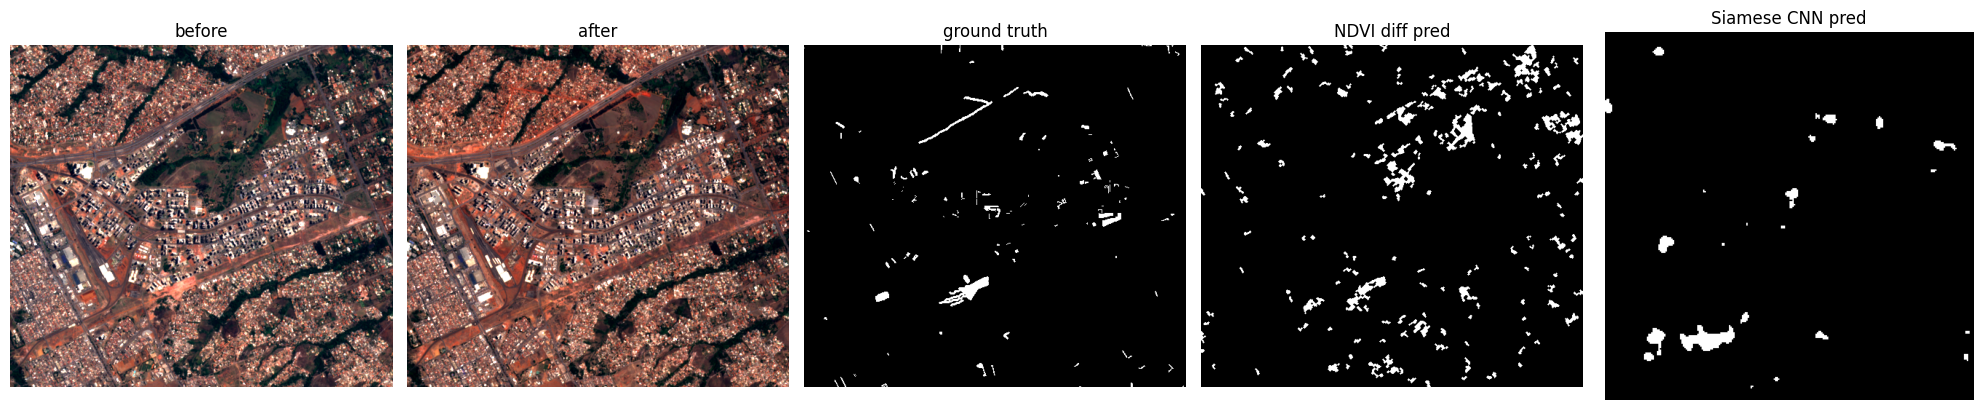

In [32]:
import torch
import matplotlib.pyplot as plt

def visualize_sample(city):
    city_dir = _find_city_dirs(_find_dir(path, "image") or path)[city]
    b1 = _load_bands(city_dir, ["imgs_1", "imgs_1_rect"])
    b2 = _load_bands(city_dir, ["imgs_2", "imgs_2_rect"])
    label_path = _find_label(labels_roots, city)
    from PIL import Image as PILImage
    gt = _binarize_label(np.array(PILImage.open(label_path).convert("L")))
    h = min(b1.shape[1], b2.shape[1], gt.shape[0])
    w = min(b1.shape[2], b2.shape[2], gt.shape[1])
    b1, b2, gt = b1[:, :h, :w], b2[:, :h, :w], gt[:h, :w]

    diff = ndvi_diff_map(b1, b2)
    diff_pred = predict_change_mask(diff)

    def rgb(bands):
        r, g, bl = bands[3], bands[2], bands[1]
        img = np.stack([r, g, bl], axis=-1)
        lo, hi = np.percentile(img, 2), np.percentile(img, 98)
        return np.clip((img - lo) / (hi - lo + 1e-6), 0, 1)

    ds = OSCDDataset(path, cities=[city], patch_size=min(h, w, 256), stride=min(h, w, 256))
    p1, p2, lbl, _ = ds[0]
    with torch.no_grad():
        out = model(p1.unsqueeze(0).to(device), p2.unsqueeze(0).to(device))
        siam_pred = out.argmax(dim=1)[0].cpu().numpy()

    fig, axes = plt.subplots(1, 5, figsize=(20,4))
    axes[0].imshow(rgb(b1)); axes[0].set_title("before")
    axes[1].imshow(rgb(b2)); axes[1].set_title("after")
    axes[2].imshow(gt, cmap="gray"); axes[2].set_title("ground truth")
    axes[3].imshow(diff_pred, cmap="gray"); axes[3].set_title("NDVI diff pred")
    axes[4].imshow(siam_pred, cmap="gray"); axes[4].set_title("Siamese CNN pred")
    for ax in axes: ax.axis("off")
    plt.tight_layout()
    plt.show()

visualize_sample(test_cities[0])

Visualizing sample from city: aguasclaras


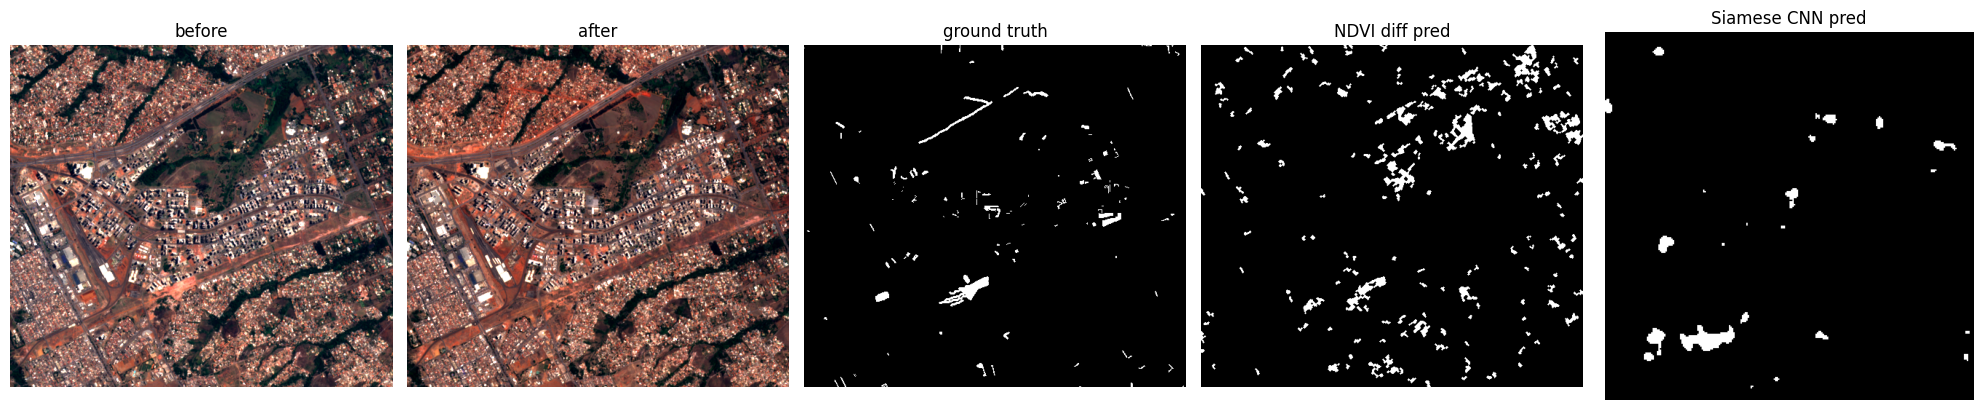

In [33]:
import torch
import matplotlib.pyplot as plt
import numpy as np # Ensure numpy is imported
from PIL import Image as PILImage # Ensure PIL Image is imported

def visualize_sample(city):
    city_dir = _find_city_dirs(_find_dir(path, "image") or path)[city]
    b1 = _load_bands(city_dir, ["imgs_1", "imgs_1_rect"])
    b2 = _load_bands(city_dir, ["imgs_2", "imgs_2_rect"])
    label_path = _find_label(labels_roots, city)

    gt = np.array(PILImage.open(label_path).convert("L"))
    gt = (gt > 127).astype(np.uint8)
    h = min(b1.shape[1], b2.shape[1], gt.shape[0])
    w = min(b1.shape[2], b2.shape[2], gt.shape[1])
    b1, b2, gt = b1[:, :h, :w], b2[:, :h, :w], gt[:h, :w]

    diff = ndvi_diff_map(b1, b2)
    diff_pred = predict_change_mask(diff)

    def rgb(bands):
        r, g, bl = bands[3], bands[2], bands[1]
        img = np.stack([r, g, bl], axis=-1)
        lo, hi = np.percentile(img, 2), np.percentile(img, 98)
        return np.clip((img - lo) / (hi - lo + 1e-6), 0, 1)

    vis_patch_size = min(h, w, 256)
    ds = OSCDDataset(path, cities=[city], patch_size=vis_patch_size, stride=vis_patch_size, require_labels=True)

    if len(ds) == 0:
        print(f"No samples available for city {city} with patch_size {vis_patch_size}.")
        return

    p1, p2, lbl, _ = ds[0]
    with torch.no_grad():
        out = model(p1.unsqueeze(0).to(device), p2.unsqueeze(0).to(device))
        siam_pred = out.argmax(dim=1)[0].cpu().numpy()

    fig, axes = plt.subplots(1, 5, figsize=(20,4))
    axes[0].imshow(rgb(b1)); axes[0].set_title("before")
    axes[1].imshow(rgb(b2)); axes[1].set_title("after")
    axes[2].imshow(gt, cmap="gray"); axes[2].set_title("ground truth")
    axes[3].imshow(diff_pred, cmap="gray"); axes[3].set_title("NDVI diff pred")
    axes[4].imshow(siam_pred, cmap="gray"); axes[4].set_title("Siamese CNN pred")
    for ax in axes: ax.axis("off")
    plt.tight_layout()
    plt.show()

# Find a test city with actual change to visualize
city_to_visualize = None
for city in test_cities:
    city_dir = _find_city_dirs(_find_dir(path, "image") or path)[city]
    label_path = _find_label(labels_roots, city)
    if label_path:
        gt_check = np.array(PILImage.open(label_path).convert("L"))
        gt_check = (gt_check > 127).astype(np.uint8)
        if np.any(gt_check == 1): # Check if there's any change pixel
            city_to_visualize = city
            break

if city_to_visualize:
    print(f"Visualizing sample from city: {city_to_visualize}")
    visualize_sample(city_to_visualize)
else:
    print("Could not find any test city with ground truth changes to visualize.")
    print("You may need to adjust your test_cities split or inspect the labels.")


In [34]:
print("diff-based baseline (test set):", diff_avg)
print("siamese CNN (test set):", siam_metrics)

diff-based baseline (test set): {'precision': np.float64(0.030694794039536843), 'recall': np.float64(0.20572581159420575), 'f1': np.float64(0.04964649325534224), 'iou': np.float64(0.025713707250955554)}
siamese CNN (test set): {'precision': 0.19885823025688243, 'recall': 0.3498395871111243, 'f1': 0.25357666401384404, 'iou': 0.14519770740461152}


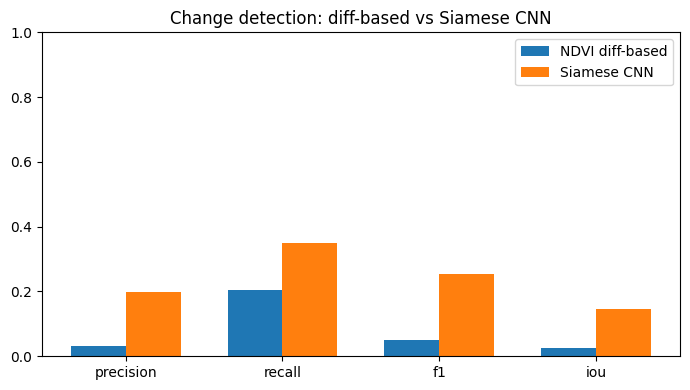

In [35]:
import matplotlib.pyplot as plt
import numpy as np

labels = ["precision", "recall", "f1", "iou"]
diff_vals = [diff_avg[k] for k in labels]
siam_vals = [siam_metrics[k] for k in labels]

x = np.arange(len(labels))
w = 0.35
plt.figure(figsize=(7,4))
plt.bar(x - w/2, diff_vals, w, label="NDVI diff-based")
plt.bar(x + w/2, siam_vals, w, label="Siamese CNN")
plt.xticks(x, labels)
plt.ylim(0, 1)
plt.legend()
plt.title("Change detection: diff-based vs Siamese CNN")
plt.tight_layout()
plt.show()